In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from itertools import pairwise

In [25]:
class Interval:

    def __init__(self, start, end):
        if start >= end: raise Exception("intervals must be valid and non-empty, they all are semi-open [a, b[, a < b")
        self.start: float = start
        self.end: float = end

    def __contains__(self, item) -> bool:
        return self.start <= item < self.end

    def __repr__(self):
        return f"[{self.start}, {self.end}["

    def get_start(self):
        return self.start

    def get_end(self):
        return self.end

    def set_start(self, new_start):
        self.start = new_start

    def set_end(self, new_end):
        self.end = new_end

In [ ]:
class HullByParts:

    def __init__(self, reference_function, subfunctions_to_intervals = {}):
        self.f: callable[float, float] = reference_function
        self.subfunctionIntervals: dict[tuple, list[Interval]] = subfunctions_to_intervals

        self.verify_validity()

    def __call__(self, x: float|list[float]|np.ndarray) -> float|np.ndarray:
        if isinstance(x, float):return self.call_float(x)
        else:                   return self.call_iter(x) 

    def call_iter(self, l) -> np.ndarray:
        return np.array(list(map(lambda x: self.call_float(x), l)))
    
    def call_float(self, x: float) -> float:
        for (slope, x_intercept), intervals in self.get_subfunctionIntervals().items():
            for interval in intervals:
                if x in interval:
                    return self.f(slope * (x - x_intercept))
        raise Exception(f"could not find {x} in the definition set of the function")

    def get_subfunctionIntervals(self) -> dict[tuple, list[Interval]]:
        return self.subfunctionIntervals

    def add_subfunctionInterval(self, params, interval):
        if params in self.get_subfunctionIntervals():
            self.subfunctionIntervals[params].append(interval)
        else:
            self.subfunctionIntervals[params] = [interval]

    def sanitize_subfunctions(self):
        for (s, x), inters in self.get_subfunctionIntervals().items():
            if s < 0:
                del self.subfunctionIntervals[(s, x)]
                self.subfunctionIntervals[(-s, -x)] = inters

    def verify_validity(self):
        for (s, _) in self.get_subfunctionIntervals().keys():
            if s == 0:
                raise Exception("slope must not be 0, subfunctions must be bijective on R")

        sorted_intervals = sorted([inter for list_inter in self.get_subfunctionIntervals().values() for inter in list_inter], key = lambda inter: inter.get_start())
        for inter1, inter2 in pairwise(sorted_intervals):
            if inter1.get_end() != inter2.get_start(): raise Exception("the function should be defined on the total range it takes values in")

    def add_subfunction(self, parameters):
        useful_intersections_left = []
        useful_intersections_right = []
        _, b = parameters

        for params, intervals in self.get_subfunctionIntervals().items():
            intersections = HullByParts.intersection_points(parameters, params)
            for i, intersection in enumerate(intersections):
                for interval in intervals:
                    if intersection in interval:
                        if intersection < b:
                            useful_intersections_left.append((params, i == 0, intersection, interval))
                        else:
                            useful_intersections_right.append((params, i == 0, intersection, interval))

        sorting_key = lambda x: x[2]
        useful_intersections_left.sort(key = sorting_key)
        useful_intersections_right.sort(key = sorting_key)

        intersection_to_remember = None
        for params, is_opposite, intersection, interval in useful_intersections_left:
            if is_opposite:
                interval.set_end(intersection)
                intersection_to_remember = intersection
            else:
                interval.set_start(intersection)
                self.add_subfunctionInterval(parameters, Interval(intersection_to_remember, intersection))
                intersection_to_remember = None

        
        for params, is_opposite, intersection, interval in useful_intersections_right:
            if is_opposite:
                interval.set_start(intersection)
                self.add_subfunctionInterval(parameters, Interval(intersection, intersection_to_remember))
                intersection_to_remember = None
            else:
                interval.set_end(intersection)
                intersection_to_remember = intersection

        if intersection_to_remember:
            final_end = max([(inter, param) for list_inter, param in self.get_subfunctionIntervals().items() for inter in list_inter], key = lambda inter, _: inter.get_end())
            self.add_subfunctionInterval(parameters, Interval(intersection_to_remember, final_end[0].get_end()))
            del self.get_subfunctionIntervals()[final_end[1]]
    

    @staticmethod
    def intersection_points(g, h):
        g_slope, g_x_inter = g
        h_slope, h_x_inter = h

        opposite_intersect = (g_x_inter*g_slope + h_x_inter*h_slope)/(g_slope + h_slope)
        if g_slope - h_slope == 0:  return [opposite_intersect]

        concurrent_intersect = (g_x_inter*g_slope - h_x_inter*h_slope)/(g_slope - h_slope)
        return [opposite_intersect, concurrent_intersect]
        


In [44]:
def plot_draw(ax, x, hull, draw_value_curves = True):
    ax.set_ylim((0, 4))
    ax.set_xlim((0, 11))

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionIntervals():
            func = lambda x: hull.f(slope * (x - x_intercept))
            ax.plot(x, func(x), color = 'black', ls = '-.', alpha = .5)

    ax.plot(x, hull(x), color='green', ls='-', lw=3)


((1, 2), [[0, 3.3333333333333335[])
((2, 4), [[3.3333333333333335, 4.6[])
((0.5, 7), [[4.6, 7.8[, [8.333333333333334, 8.6[, [9.666666666666666, 11[])
((2, 8), [[7.8, 8.333333333333334[])
((2, 9), [[8.6, 9.666666666666666[])
-------------------------------
((1, 2), [[0, 3.3333333333333335[])
((2, 4), [[3.3333333333333335, 4.6[])
((0.5, 7), [[4.6, 7.8[, [8.333333333333334, 8.5[, [9.666666666666666, 11[])
((2, 8), [[7.8, 8.333333333333334[])
((2, 9), [[8.666666666666666, 9.2[])
((0.5, 10), [[8.5, 8.666666666666666[])


Exception: could not find 9.206999999999999 in the definition set of the function

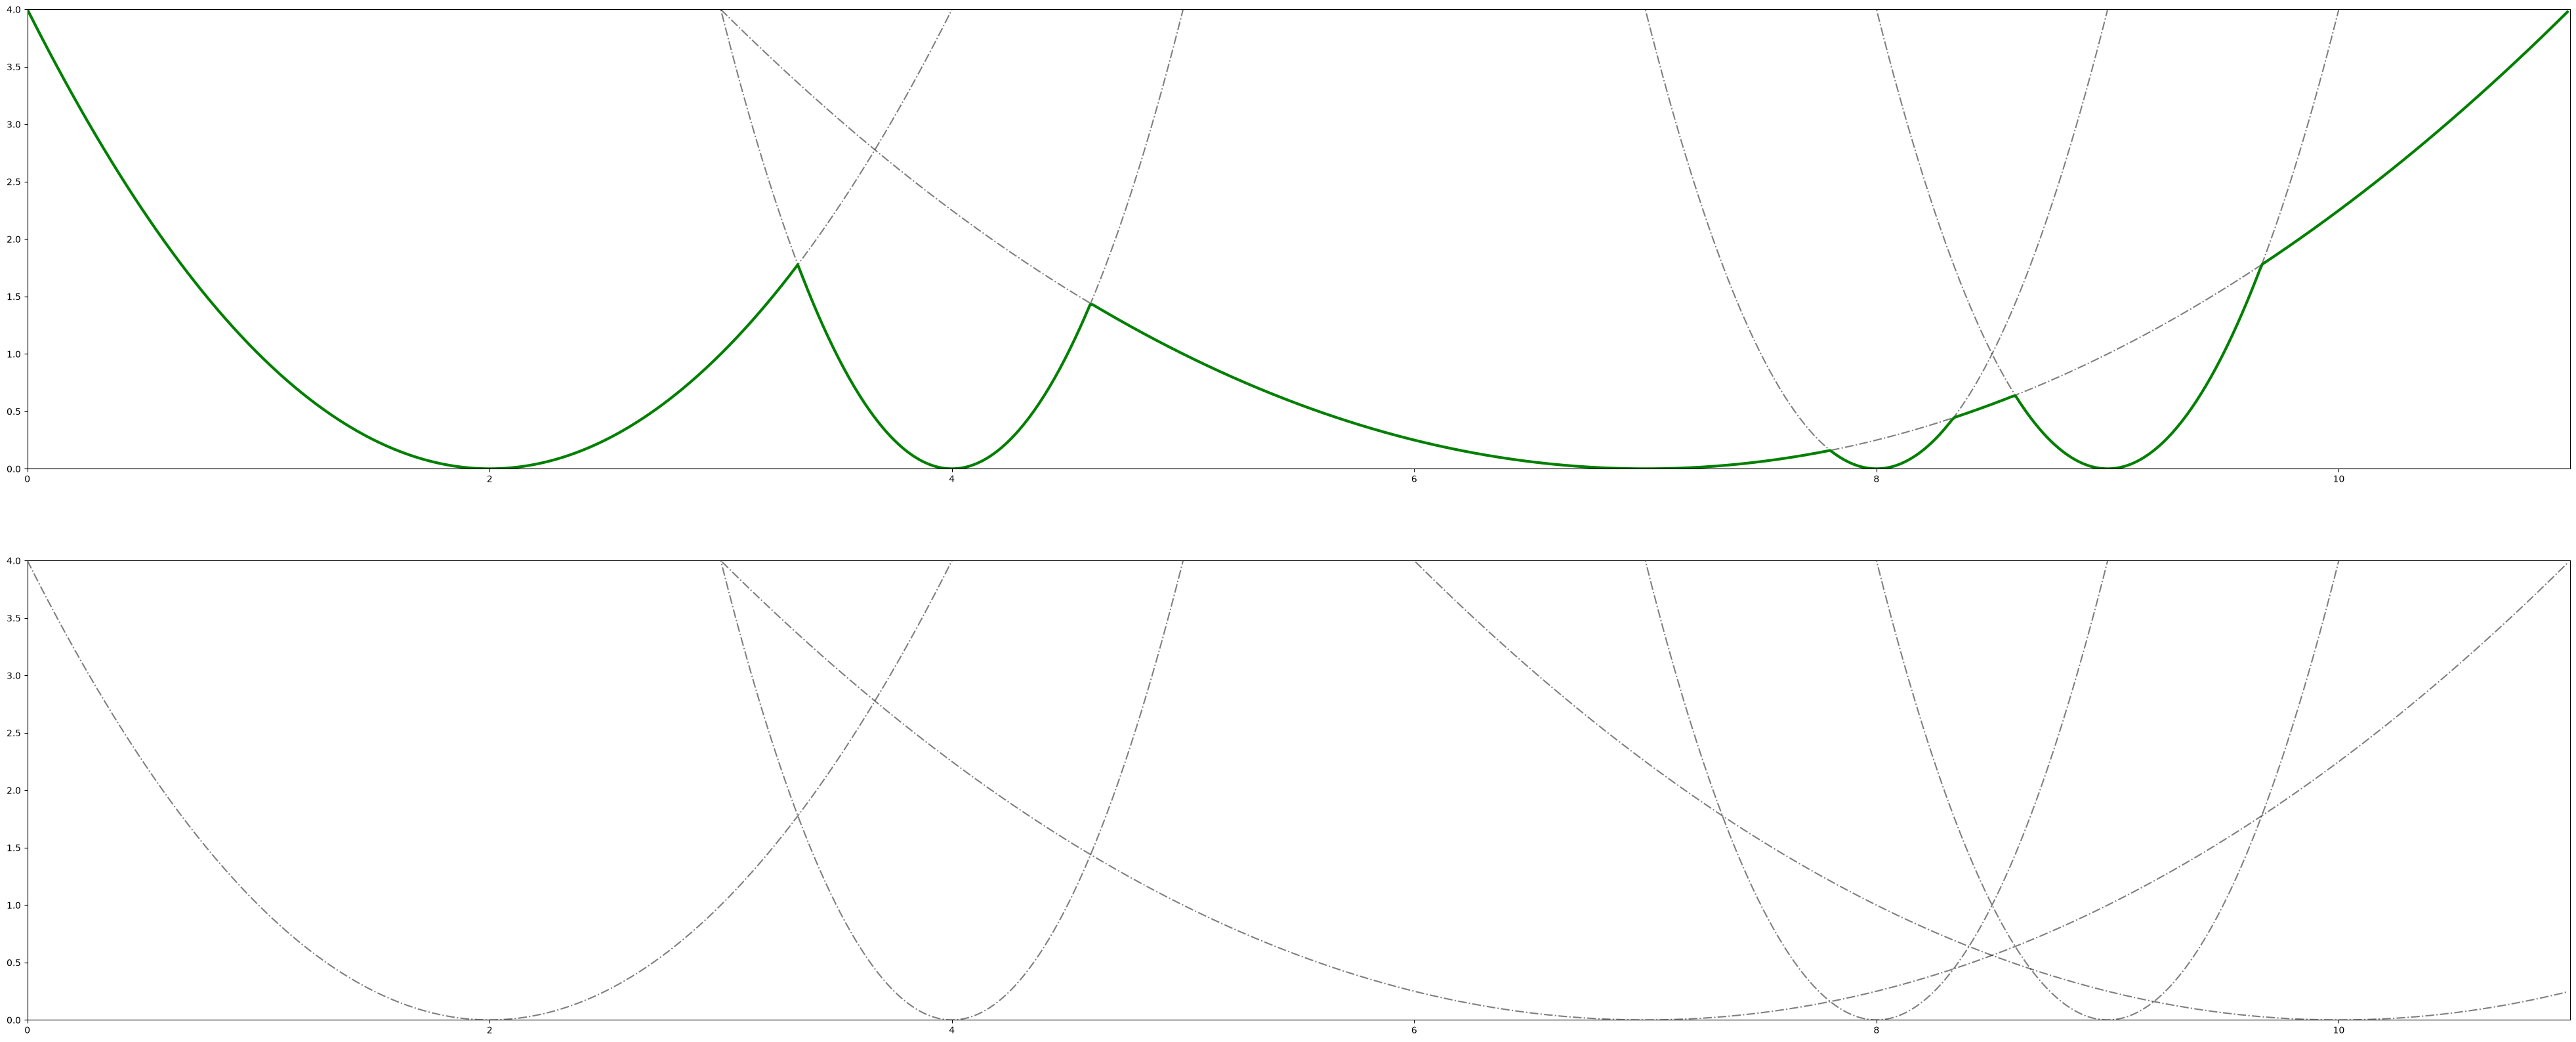

In [45]:
width = 50
height = 10
my_range = (0, 11)

data = {(1, 2): [Interval(0, 10./3)],
        (2, 4): [Interval(10./3, 4.6)],
        (.5, 7): [Interval(4.6, 7.8), Interval(25./3, 8.6), Interval(29./3, 11)],
        (2, 8): [Interval(7.8, 25./3)],
        (2, 9): [Interval(8.6, 29./3)]}

#values_taken = [-4, -3.356, -2.5, -2.4, -1, 2, 8, 10, 13.24]
x = np.linspace(*my_range, 1000, endpoint=False)

power = lambda e: lambda x: x**e
f = power(2)
string = "x^2"

subplots = 2
fig, axs = plt.subplots(subplots, 1, figsize=(width, subplots*height))

hull = HullByParts(f, data)
for obj in hull.get_subfunctionIntervals().items():
    print(obj)
print("-------------------------------")
plot_draw(axs[0], x, hull, draw_value_curves=True)


hull.add_subfunction((.5, 10))
for obj in hull.get_subfunctionIntervals().items():
    print(obj)
plot_draw(axs[1], x, hull, draw_value_curves=True)
    
fig.show()

/tmp/ipykernel_1539416/3760548315.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


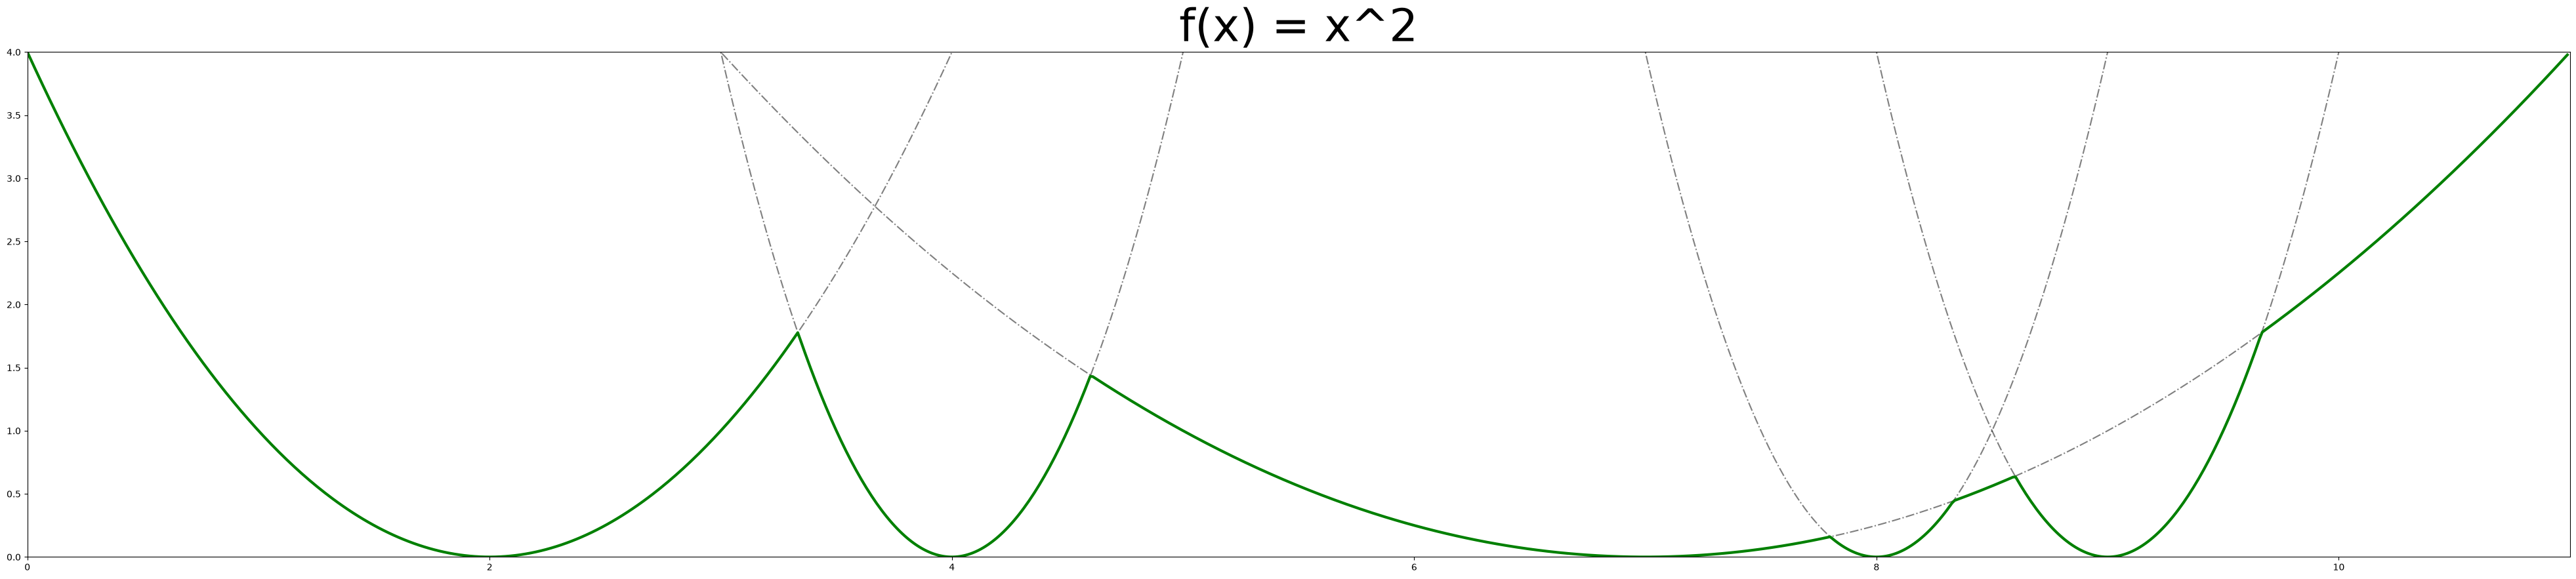

In [ ]:
width = 50
height = 10
my_range = (0, 11)

#values_taken = [-4, -3.356, -2.5, -2.4, -1, 2, 8, 10, 13.24]


x = np.linspace(*my_range, 1000, endpoint=False)

power = lambda e: lambda x: x**e
distance_functions = [power(2)]
functions_expression = ["x^2"]

subplots = len(distance_functions)
fig, axs = plt.subplots(subplots, 1, figsize=(width, subplots*height))


for ax, f, string in zip([axs], distance_functions, functions_expression):
    plot_draw(ax, x, HullByParts(f, data), draw_value_curves=True)
    ax.set_title(label=f"f(x) = {string}", fontdict={'fontsize':50})

fig.show()